# Preface
If you are new to Colab, please familiarize yourself with it by starting with the introduction (https://colab.research.google.com/notebooks/intro.ipynb) and then working yourself through a small tutorial:
https://colab.research.google.com/drive/1umhPVtUWH8yHD2l9A_G4fdttmgmSgC0Q

Please, always save a copy of the notebook on your google drive before you start working and only edit that one. In addition, always switch the runtime to Python 3 and for most **later** exercises it is recommended to also switch to a GPU runtime.

**Important**: Make sure **not** to spend up your GPU resources for earlier tasks that could also easily run on a CPU.

# Exercise 1 - Machine Learning Basics

In the first part of this exercise we will will apply linear regression to a dataset of brain properties. In the second part we will apply logistic regresseion to classify different types of iris flowers.

This exercise is based on ["Learning scikit-learn -- An Introduction to Machine Learning in Python @ PyData Chicago 2016"](https://github.com/rasbt/pydata-chicago2016-ml-tutorial).

Before we start we need to download the two datasets named "dataset_brain.txt" and "dataset_iris.txt" from a shared google drive to the virtual machine of colab or our local machine so we will have it available:

In [ ]:
! wget -nc https://drive.google.com/uc?id=1lBQ55AHVbX29bEMNfLOunOE5PwYAKDpg -O dataset_iris.txt

In [ ]:
!ls

# Table of Contents

* [Classification](#3-Introduction-to-Classification)
    * [The Iris dataset](#The-Iris-dataset)
    * [Class label encoding](#Class-label-encoding)
    * [Scikit-learn's in-build datasets](#Scikit-learn's-in-build-datasets)
    * [Test/train splits](#Test/train-splits)
    * [Logistic Regression](#Logistic-Regression)
    * [K-Nearest Neighbors](#K-Nearest-Neighbors)
    

# Classification

## The Iris dataset

### Task 1: The Iris flower dataset is stored in file **`dataset_iris.txt`**. Read in the dataset using a pandas DataFrame and have a look at the first entries.
*Hints*:
- use `open("path/to/file")`
- `readlines()` is a useful method
- what is the separator in the iris dataset?

In [1]:
import pandas as pd

df = pd.read_csv('data/dataset_iris.txt', comment='#')
df.head()



,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


We now need to create a 150x4 design matrix containing only our feature values. In order to do that, we need to strip the class column from the dataset. We use the [**`iloc`**](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.iloc.html) function for that:

> `DataFrame.iloc`
>
> Purely integer-location based indexing for selection by position.



In [2]:
X = df.iloc[:, :4]
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


And now we get 150$\times$4 numpy array (design matrix) by using the values function:

In [3]:
X = X.values
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

However, we also need a NumPy array containing the class labels in order to classify. Let's get the class column and create a NumPy array out of it:

In [4]:
y = df['class'].values
y

<StringArray>
[   'Iris-setosa',    'Iris-setosa',    'Iris-setosa',    'Iris-setosa',
    'Iris-setosa',    'Iris-setosa',    'Iris-setosa',    'Iris-setosa',
    'Iris-setosa',    'Iris-setosa',
 ...
 'Iris-virginica', 'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
 'Iris-virginica', 'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
 'Iris-virginica', 'Iris-virginica']
Length: 150, dtype: str

We could also just inspect the targets by only looking at unique values:

In [5]:
import numpy as np

np.unique(y)

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

## Class label encoding

We will now use the **`LabelEncoder`** class to convert the class labels into numerical labels:

In [6]:
from sklearn.preprocessing import LabelEncoder

l_encoder = LabelEncoder()
l_encoder.fit(y)
l_encoder.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

Simply, by using **`transform`**, we can convert it into numerical targets

In [7]:
y_enc = l_encoder.transform(y)
y_enc

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

Or just the unique values:

In [8]:
np.unique(y_enc)

array([0, 1, 2])

We can also convert it back by using **`inverse_transform`**:

In [9]:
np.unique(l_encoder.inverse_transform(y_enc))

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

## Scikit-learn's in-build datasets

Scikit-learn has also a couple of [built-in datasets](http://scikit-learn.org/stable/datasets/index.html). The iris dataset is also included, which you can simply load:

In [10]:
from sklearn.datasets import load_iris

iris = load_iris()
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

We get the feature design matrix by calling data:

In [11]:
 iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

And the target array:

In [12]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

## Test/train splits

OK, now we need to split the dataset again in training and testing. Let's first assign the design matrix to X and the target to y:

In [13]:
X, y = iris.data[:, :2], iris.target
# ! We only use 2 features for visual purposes

How many example do we have of each class?

In [14]:
print('Class labels:', np.unique(y))
print('Class proportions:', np.bincount(y))

Class labels: [0 1 2]
Class proportions: [50 50 50]


### Task 2: Split the dataset in 40% testing and 60% training sets.
- How many examples of each class do you expect in the training set?
- How many are there? What happened?
- What happens if you don't shuffle?
- Can you create datasets in which each class is equally distributed?

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

print('Actual in training:', np.bincount(y_train))

X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
print('Stratified actual in training:', np.bincount(y_train_strat))

Actual in training: [27 31 32]
Stratified actual in training: [30 30 30]


- How many examples of each class do you expect in the training set?

We expect 60% of training sets so 30% for each feature

- How many are there? What happened?

The actual training set is [27 31 32]

- What happens if you don't shuffle?

The dataset is ordered by class. Without shuffling, the training set would contain mostly classes 0 and 1.

- Can you create datasets in which each class is equally distributed?

Yes, using stratify=y

### Task 3: Plot the sepal length vs the sepal width of the training set for the different classes in a scatter plot. You can set different colors for the classes with `c=y_train`

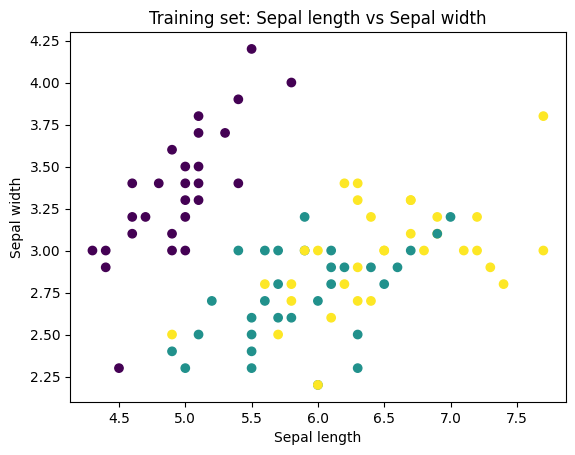

In [16]:
import matplotlib.pyplot as plt

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('Training set: Sepal length vs Sepal width')
plt.show()

## Logistic Regression

Let's perform a classification using logistic regression:

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(solver='newton-cg',
                        random_state=42) #always use multinomial in new version

lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

OK, how do we evaluate the classification? We can chose one of the [classification performance measures](http://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics).

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
)


print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.2f}")
print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.2f}")

Accuracy: 0.85
Precision: 0.86
Recall: 0.85


Or we use the classification report function:

In [20]:
print('Classification Report:\n', classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.86      0.63      0.73        19
           2       0.70      0.89      0.78        18

    accuracy                           0.85        60
   macro avg       0.85      0.84      0.84        60
weighted avg       0.86      0.85      0.85        60



Finally, we would like to plot the decision regions and our data in order to see how the classifier categorized the events. We have highlighted the test data.

[Text(0.5, 0, 'Sepal length / cm'), Text(0, 0.5, 'Sepal width / cm')]

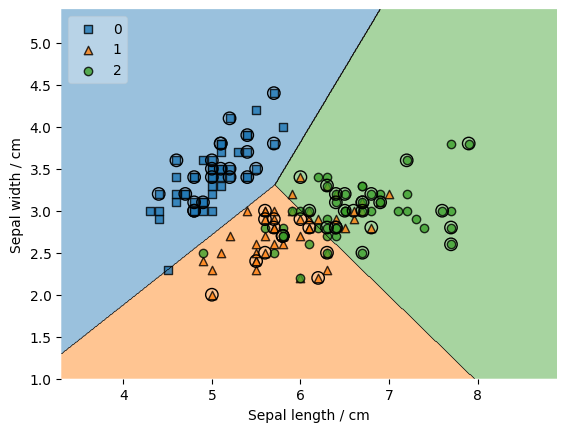

In [21]:
from mlxtend.plotting import plot_decision_regions

ax = plot_decision_regions(X=X, y=y, clf=lr, X_highlight=X_test, legend=2)
ax.set(
    xlabel="Sepal length / cm",
    ylabel="Sepal width / cm",
)

## K-Nearest Neighbors

### Task 6 (Bonus): Perform a classification using [K-nearest neighbors classifier](http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html), evaluate the performance and show the decision regions.

Accuracy: 0.77


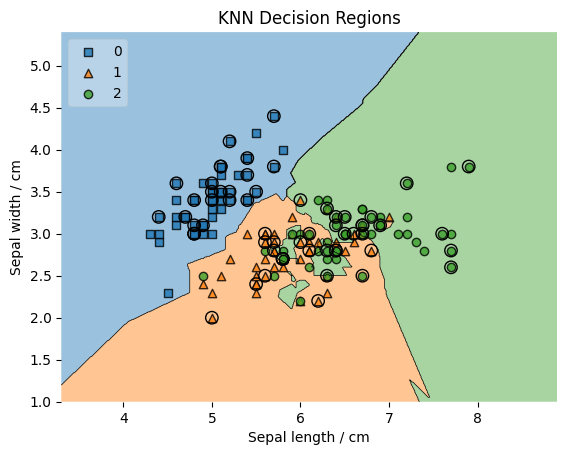

In [ ]:
from sklearn.neighbors import KNeighborsClassifier


knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred_knn):.2f}')

ax = plot_decision_regions(X=X, y=y, clf=knn, X_highlight=X_test, legend=2)
ax.set(
    xlabel='Sepal length / cm',
    ylabel='Sepal width / cm',
    title='KNN Decision Regions'
);
